Notebook to test the visualisation functions in visualization/candle_plots.py

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

# Make sure notebook can import from src/
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis


In [2]:
from src.data.load_candle_data import (
    load_candle_splits,
    clean_candle_splits,
    describe_split,
    validate_clean_split,
    compute_log_returns,
    get_channel
)

from src.visualization.candle_plots import (
    plot_return_correlation_heatmap,
    plot_intraday_channel,
    plot_intraday_log_returns,
    plot_average_intraday_abs_return,
    compute_persistence_movement_summary,
    compute_variance_ratios,
    compute_variance_scaling_hurst,
    plot_return_autocorrelation,
)

In [3]:
DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/Shared drives/Vishal/data/cached_datasets/exp-1m-95s-24y/session"
)

DATA_DIR.exists(), DATA_DIR

(True,
 PosixPath('/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/Shared drives/Vishal/data/cached_datasets/exp-1m-95s-24y/session'))

In [4]:
train_raw, val_raw, test_raw = load_candle_splits(DATA_DIR)

describe_split(train_raw, "raw train")
describe_split(val_raw, "raw val")
describe_split(test_raw, "raw test")


raw train
---------
num samples: 167
T: 391
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 1
first day: 2024-01-02 00:00:00
first x shape: (391, 93, 6)
first aux: None

raw val
-------
num samples: 20
T: 391
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 0
first day: 2024-09-03 00:00:00
first x shape: (391, 93, 6)
first aux: None

raw test
--------
num samples: 62
T: 391
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 2
first day: 2024-10-01 00:00:00
first x shape: (391, 93, 6)
first aux: None


In [5]:
train, val, test = clean_candle_splits(train_raw, val_raw, test_raw)

describe_split(train, "clean train")
describe_split(val, "clean val")
describe_split(test, "clean test")
print("\n")
validate_clean_split(train)
validate_clean_split(val)
validate_clean_split(test)


clean train
-----------
num samples: 167
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 1
first day: 2024-01-02 00:00:00
first x shape: (390, 93, 6)
first aux: None

clean val
---------
num samples: 20
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 0
first day: 2024-09-03 00:00:00
first x shape: (390, 93, 6)
first aux: None

clean test
----------
num samples: 62
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 2
first day: 2024-10-01 00:00:00
first x shape: (390, 93, 6)
first aux: None


Validation passed for 167 samples.
Validation passed for 20 samples.
Validation passed for 62 samples.


In [ ]:
x, aux, day = train["samples"][0]

returns = compute_log_returns(x=x,split=train,channels=['close'])

print("day:", day)
print("x shape:", tuple(x.shape))
print("returns shape:", tuple(returns.shape))
print("returns mean:", returns.mean().item())
print("returns std:", returns.std().item())
print("returns has NaN:", torch.isnan(returns).any().item())
print("returns has Inf:", torch.isinf(returns).any().item())

In [ ]:
#check for error data - flag assets where there are large intraday jumps in prices
threshold = 100
flagged_asset_ids = set()

for x, _, day in train["samples"]:
    open_prices = get_channel(x, train, "open")
    close_prices = get_channel(x, train, "close")

    diff = open_prices[1:] - close_prices[:-1]

    asset_has_large_gap = diff.abs().ge(threshold).any(dim=0)

    flagged_ids_this_day = torch.where(asset_has_large_gap)[0].tolist()

    flagged_asset_ids.update(flagged_ids_this_day)

flagged_tickers = [
    train["asset_cols"][asset_id]
    for asset_id in sorted(flagged_asset_ids)
]

flagged_tickers

In [ ]:
#check for errors - flag assets where there are large overnight moves in prices. These will likely be stock splits
threshold = 100
flagged_asset_ids = set()

samples = train["samples"]

for sample_idx in range(1, len(samples)):
    x_prev, _, prev_day = samples[sample_idx - 1]
    x_curr, _, curr_day = samples[sample_idx]

    prev_close = get_channel(x_prev, train, "close")[-1]
    curr_open = get_channel(x_curr, train, "open")[0]

    gap = curr_open - prev_close

    asset_has_large_gap = gap.abs().ge(threshold)

    flagged_ids_this_gap = torch.where(asset_has_large_gap)[0].tolist()

    flagged_asset_ids.update(flagged_ids_this_gap)

flagged_tickers = [
    train["asset_cols"][asset_id]
    for asset_id in sorted(flagged_asset_ids)
]

flagged_tickers

In [ ]:
fig, ax, corr, labels = plot_return_correlation_heatmap(
    split=train,
    channel='close',
    sample_indices=None,
    assets=None,
    reorder=False,
    show_tickers=True,
)

print("corr shape:", corr.shape)
print("num labels:", len(labels))

In [ ]:
fig, ax, corr_clustered, labels_clustered = plot_return_correlation_heatmap(
    split=train,
    channel='close',
    sample_indices=[148],
    assets=None,
    reorder=True,
    cluster_by_abs=True,
    show_tickers=True,
)

print("clustered corr shape:", corr_clustered.shape)
print("first 10 clustered labels:", labels_clustered[:10])

In [ ]:
selected_assets = ["AAPL", "AMD", "AMZN", "MSFT"]

fig, ax, corr_small, labels_small = plot_return_correlation_heatmap(
    split=train,
    channel='close',
    sample_indices=None,
    assets=selected_assets,
    reorder=False,
    show_tickers=True,
)

print("small corr shape:", corr_small.shape)
print("labels:", labels_small)

In [ ]:
fig, ax = plot_intraday_channel(
    split=train,
    channel='close',
    sample_indices=[158],
    assets="PPG",
    normalize=False,
    mode="concat",
    max_samples=None
)

In [ ]:
fig, ax = plot_intraday_channel(
    split=train,
    channel='volume',
    sample_indices=[100],
    assets=["GOOG"],
    normalize=False,
    mode="overlay",
    max_samples=None
)

In [ ]:
fig, ax = plot_intraday_log_returns(
    split=train,
    channel='close',
    sample_indices=None,
    assets="AAPL",
    mode="concat",
)

In [ ]:
fig, ax = plot_intraday_log_returns(
    split=train,
    channel='open',
    sample_indices=slice(100, 110),
    assets="AAPL",
    mode="concat",
)

In [ ]:
fig, ax, avg_abs_return, std_abs_return = plot_average_intraday_abs_return(
    split=train,
    channel='close',
    sample_indices=None,
    mode="profile",
)


In [ ]:
fig, ax, avg_abs_return, std_abs_return = plot_average_intraday_abs_return(
    split=train,
    channel='close',
    sample_indices=slice(145,155),
    mode="concat",
    assets=None,
)

In [6]:
persistence_summary = compute_persistence_movement_summary(
    split=train,
    channel="close",
)

display(
    persistence_summary
    .set_index("horizon")[
        [
            "persistence_raw_mae",
            "persistence_raw_rmse",
            "cumulative_log_change_std",
            "cumulative_log_change_mae",
            "median_abs_cumulative_log_change",
            "cumulative_log_change_q05",
            "cumulative_log_change_q25",
            "cumulative_log_change_q50",
            "cumulative_log_change_q75",
            "cumulative_log_change_q95",
        ]
    ]
    .style.format("{:.6e}")
)

,persistence_raw_mae,persistence_raw_rmse,cumulative_log_change_std,cumulative_log_change_mae,median_abs_cumulative_log_change,cumulative_log_change_q05,cumulative_log_change_q25,cumulative_log_change_q50,cumulative_log_change_q75,cumulative_log_change_q95
horizon,,,,,,,,,,
1,9.811319e-02,2.939161e-01,5.423372e-04,3.693187e-04,2.621307e-04,-8.386475e-04,-2.635862e-04,0.000000e+00,2.603328e-04,8.104517e-04
5,2.083932e-01,5.923615e-01,1.136297e-03,7.910622e-04,5.706483e-04,-1.766182e-03,-5.802659e-04,0.000000e+00,5.599532e-04,1.672409e-03
15,3.557708e-01,1.006888e+00,1.921779e-03,1.344961e-03,9.812415e-04,-2.942178e-03,-9.561556e-04,0.000000e+00,1.002781e-03,2.857838e-03
30,4.948727e-01,1.402900e+00,2.658520e-03,1.870376e-03,1.370796e-03,-4.066008e-03,-1.328549e-03,5.029654e-05,1.411018e-03,3.957482e-03
60,6.953295e-01,1.978081e+00,3.696775e-03,2.623846e-03,1.940065e-03,-5.682868e-03,-1.857839e-03,1.054133e-04,2.014495e-03,5.561316e-03


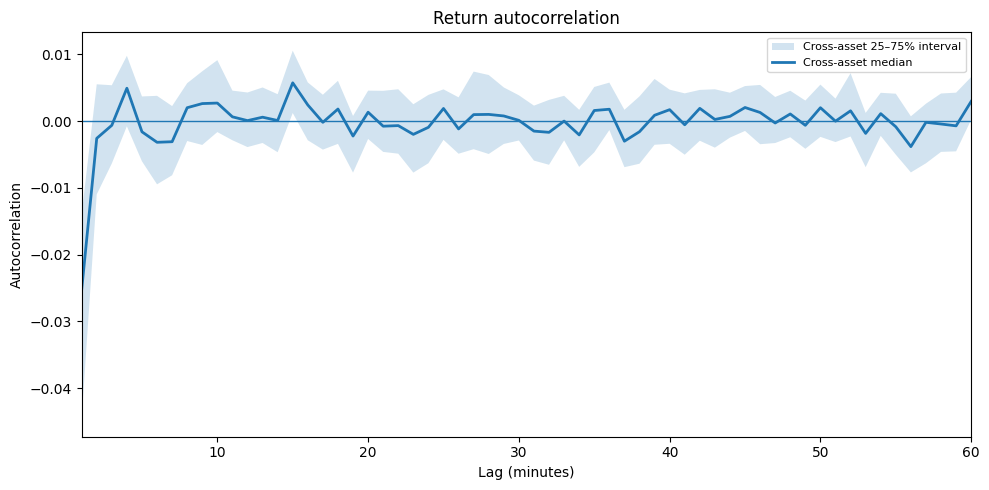

In [7]:
_, _, return_acf = plot_return_autocorrelation(
    split=train,
    channel="close",
    max_lag=60,
    min_lag=1,
    kind="return",
    centre="median",
)

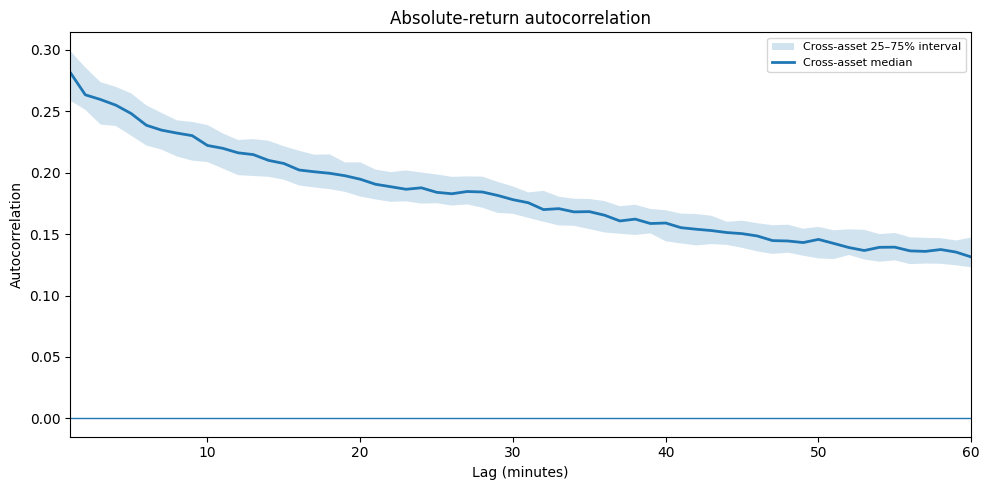

In [8]:
_, _, absolute_return_acf = plot_return_autocorrelation(
    split=train,
    channel="close",
    max_lag=60,
    min_lag=1,
    kind="absolute",
    centre="median",
)

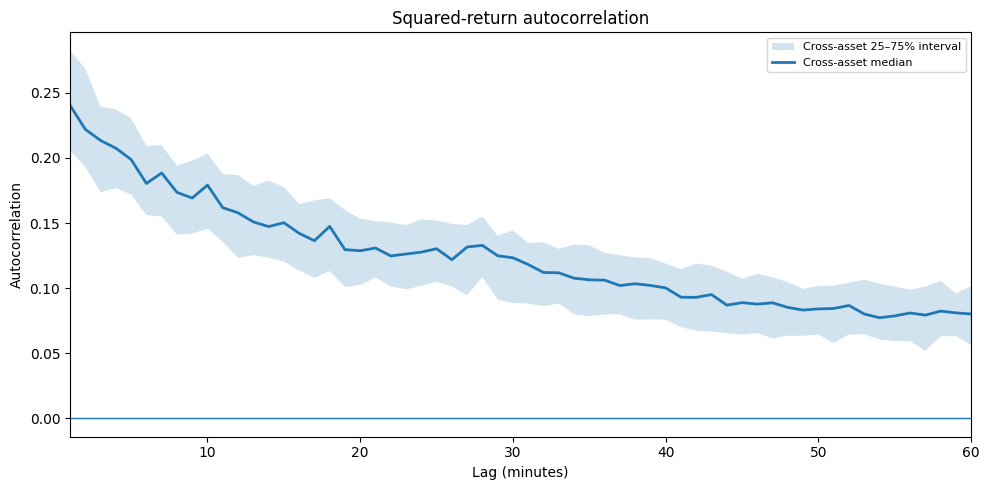

In [9]:
_, _, squared_return_acf = plot_return_autocorrelation(
    split=train,
    channel="close",
    max_lag=60,
    min_lag=1,
    kind="squared",
    centre="median",
)

In [10]:
variance_ratio_summary = compute_variance_ratios(
    split=train,
    channel="close",
    horizons=(1, 5, 15, 30, 60),
)

display(
    variance_ratio_summary
    .set_index("horizon")[
        [
            "mean_variance_ratio",
            "median_variance_ratio",
            "q25_variance_ratio",
            "q75_variance_ratio",
            "std_variance_ratio",
        ]
    ]
    .style.format("{:.4f}")
)

,mean_variance_ratio,median_variance_ratio,q25_variance_ratio,q75_variance_ratio,std_variance_ratio
horizon,,,,,
1,1.0000,1.0000,1.0000,1.0000,0.0000
5,0.8912,0.8996,0.8653,0.9221,0.0447
15,0.8127,0.8216,0.7883,0.8571,0.0551
30,0.7543,0.7608,0.7211,0.7980,0.0631
60,0.6843,0.6911,0.6344,0.7365,0.0687


In [11]:
hurst_by_asset = compute_variance_scaling_hurst(
    split=train,
    channel="close",
    scales=(1, 2, 5, 10, 15, 30, 60),
)

display(
    hurst_by_asset[
        ["hurst", "r_squared"]
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .style.format("{:.4f}")
)

,hurst,r_squared
count,93.0000,93.0000
mean,0.4546,0.9997
std,0.0124,0.0003
min,0.4218,0.9985
25%,0.4469,0.9995
50%,0.4566,0.9998
75%,0.4633,0.9999
max,0.4803,1.0000
